# Schrödinger Bound States in a Potential Well

This notebook discretizes the one-dimensional Schrödinger Hamiltonian

$$H=-\frac{1}{2}\frac{d^2}{dx^2}+V(x)$$

for an attractive Gaussian well. Negative-energy eigenstates are bound states. A low-energy polynomial filter approximates imaginary-time cooling toward the ground bound state.


## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a one-dimensional attractive potential well.

**QSVT implementation.** It uses an exponential low-energy filter to isolate bound-state support. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Finite-difference diagonalization validates energies and filtered densities. For larger discretized Schrödinger operators, low-energy polynomial filters are a QSVT primitive for bound-state preparation and spectral selection.


## Variable definitions

- `n_points`: number of spatial grid points.
- `length`: physical domain length.
- `x`, `dx`: grid coordinates and spacing.
- `negative_laplacian_unit`: finite-difference kinetic-energy operator before scaling.
- `potential`: attractive potential well.
- `H`: discretized Schrodinger Hamiltonian.
- `eigenvalues`, `eigenvectors`: exact spectrum and eigenvectors.
- `n_bound`: number of negative-energy bound states.
- `center`, `half_width`: midpoint and half-width of the spectrum.
- `A`: rescaled Hamiltonian.
- `beta`: imaginary-time filter strength.
- `coeffs`: exponential polynomial coefficients.
- `psi0`, `psi_filtered`: initial state and filtered state.
- `ground_state`: exact ground-state vector.
- `ground_overlap`: overlap of the filtered state with the ground state.
- `filtered_energy`: energy expectation of the filtered state.
- `fig`, `axes`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.pde import dirichlet_laplacian_1d
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian
from qsvt.templates import exponential_approximation_polynomial

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_points = 72
length = 12.0
dx = length / (n_points + 1)
x = np.linspace(-0.5 * length + dx, 0.5 * length - dx, n_points)

_, negative_laplacian_unit = dirichlet_laplacian_1d(n_points, length=length)
potential = -8.0 * np.exp(-(x**2) / (2.0 * 1.1**2))
H = 0.5 * negative_laplacian_unit + np.diag(potential)

eigenvalues, eigenvectors = eigh_hermitian(H)
n_bound = int(np.sum(eigenvalues < 0.0))

print(f"Eigenvalues [model energy units]: {eigenvalues[:6]}")
print(f"Number of Bound States [states]: {n_bound}")

Eigenvalues [model energy units]: [-6.7968 -4.5635 -2.6903 -1.2181 -0.2361  0.1906]
Number of Bound States [states]: 5


## Potential-well schematic

The attractive well has several negative-energy bound states. The filter later amplifies the low-energy subspace.


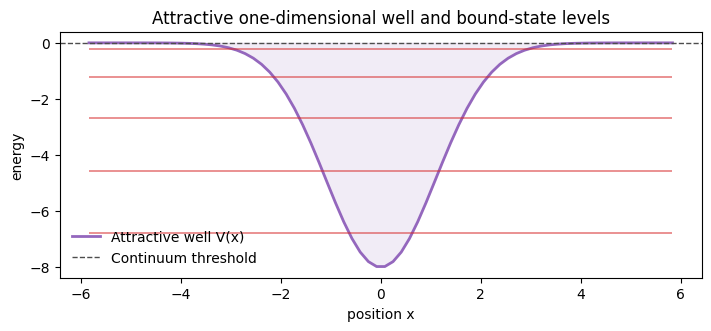

In [3]:
fig, ax = plt.subplots(figsize=(7.0, 3.2), constrained_layout=True)

ax.plot(x, potential, color="tab:purple", linewidth=2.0, label="Attractive well V(x)")
for energy in eigenvalues[:n_bound]:
    ax.hlines(energy, x[0], x[-1], color="tab:red", alpha=0.55, linewidth=1.3)
ax.axhline(0.0, color="0.3", linestyle="--", linewidth=1.0, label="Continuum threshold")
ax.fill_between(
    x, potential, 0.0, where=potential < 0.0, color="tab:purple", alpha=0.12
)
ax.set_xlabel("position x")
ax.set_ylabel("energy")
ax.set_title("Attractive one-dimensional well and bound-state levels")
ax.legend(frameon=False)
plt.show()

## Low-energy polynomial filter

Map the lowest Hamiltonian eigenvalue to `+1` and the highest to `-1`, then apply a bounded exponential-like polynomial. This damps high-energy components and keeps the ground-state component.


In [4]:
center = 0.5 * (eigenvalues[0] + eigenvalues[-1])
half_width = 0.5 * (eigenvalues[-1] - eigenvalues[0])
A = (center * np.eye(n_points) - H) / half_width

beta = 8.0
degree = 18
coeffs = exponential_approximation_polynomial(degree=degree, beta=beta)

psi0 = np.exp(-(x**2) / 4.0)
psi0 = psi0 / np.linalg.norm(psi0)
psi_filtered = apply_polynomial_to_hermitian(A, coeffs) @ psi0
psi_filtered = psi_filtered / np.linalg.norm(psi_filtered)

ground_state = eigenvectors[:, 0]
ground_overlap = np.abs(np.vdot(ground_state, psi_filtered)) ** 2
filtered_energy = np.real(psi_filtered @ (H @ psi_filtered))

print(f"Ground State Overlap [probability]: {ground_overlap}")
print(f"Filtered Energy [model energy units]: {filtered_energy}")

Ground State Overlap [probability]: 0.9505375069652005
Filtered Energy [model energy units]: -6.586964339925885


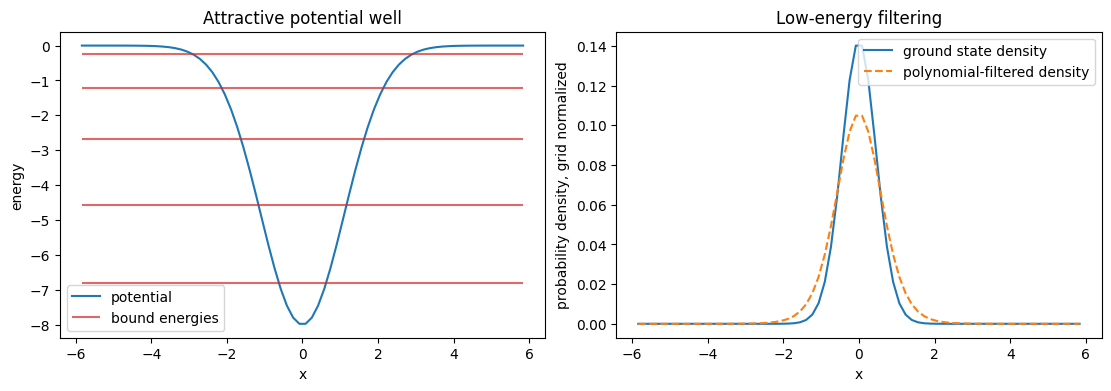

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

axes[0].plot(x, potential, label="potential")
axes[0].hlines(
    eigenvalues[:n_bound],
    x[0],
    x[-1],
    color="tab:red",
    alpha=0.7,
    label="bound energies",
)
axes[0].set_xlabel("x")
axes[0].set_ylabel("energy")
axes[0].set_title("Attractive potential well")
axes[0].legend()

axes[1].plot(x, ground_state**2, label="ground state density")
axes[1].plot(x, psi_filtered**2, "--", label="polynomial-filtered density")
axes[1].set_xlabel("x")
axes[1].set_ylabel("probability density, grid normalized")
axes[1].set_title("Low-energy filtering")
axes[1].legend()

plt.show()

## Validation

Compact checks for the bound-state spectrum and ground-state filtering.


In [6]:
assert n_bound >= 3
assert eigenvalues[0] < -6.0
assert eigenvalues[n_bound - 1] < 0.0
assert ground_overlap > 0.9
assert abs(filtered_energy - eigenvalues[0]) < 0.5

print(
    "lowest_energies [model energy units]:",
    np.array2string(eigenvalues[:6], precision=4),
)
print(f"n_bound [states]: {n_bound}")
print(f"ground_overlap [probability]: {ground_overlap:.4f}")
print(f"filtered_energy [model energy units]: {filtered_energy:.4f}")
print("validation: passed")

lowest_energies [model energy units]: [-6.7968 -4.5635 -2.6903 -1.2181 -0.2361  0.1906]
n_bound [states]: 5
ground_overlap [probability]: 0.9505
filtered_energy [model energy units]: -6.5870
validation: passed
